In [6]:
rs = 1234 
import pandas as pd
import pickle
import statsmodels.api as sm
import numpy as np
from tqdm.notebook import tqdm
from sklearn.inspection import permutation_importance 
tqdm.pandas()

df = pd.read_csv('new_cleaned_data.csv')
df.head()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,term,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,360.0,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,360.0,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,360.0,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,360.0,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,360.0,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [7]:
#import pickled file
with open('finaldataset.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract the components
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

In [8]:
#checking to make sure my pickle file wasn't corrupted or eliminating a entire value
with open('finaldataset.pkl', 'rb') as f:
    data = pickle.load(f)
    
print("Class counts in pickle:")
print("y_train:", data['y_train'].value_counts())
print("y_test:", data['y_test'].value_counts())  # or data['y_test'] depending on your pickle structure

Class counts in pickle:
y_train: status
0         85801
1         15223
Name: count, dtype: int64
y_test: status
0         21412
1          3845
Name: count, dtype: int64


/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1101: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


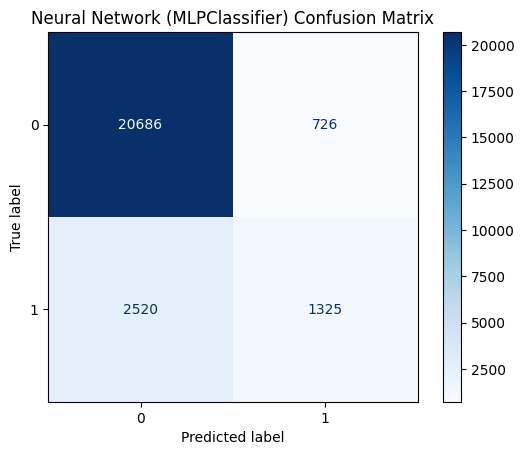

/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1101: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1101: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1101: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/neural_netwo


Neural Network CV Stats:
Accuracy - CV Avg: 0.873, Std: 0.002
Precision - CV Avg: 0.666, Std: 0.025
Recall - CV Avg: 0.322, Std: 0.011
Balanced Accuracy - CV Avg: 0.647, Std: 0.004


/var/folders/gn/h0rxtf8n1sx84t5_g7gxgxqh0000gn/T/ipykernel_54452/507763048.py:95: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=feat_imp, y='Variable', x='MeanImp', ci=None)


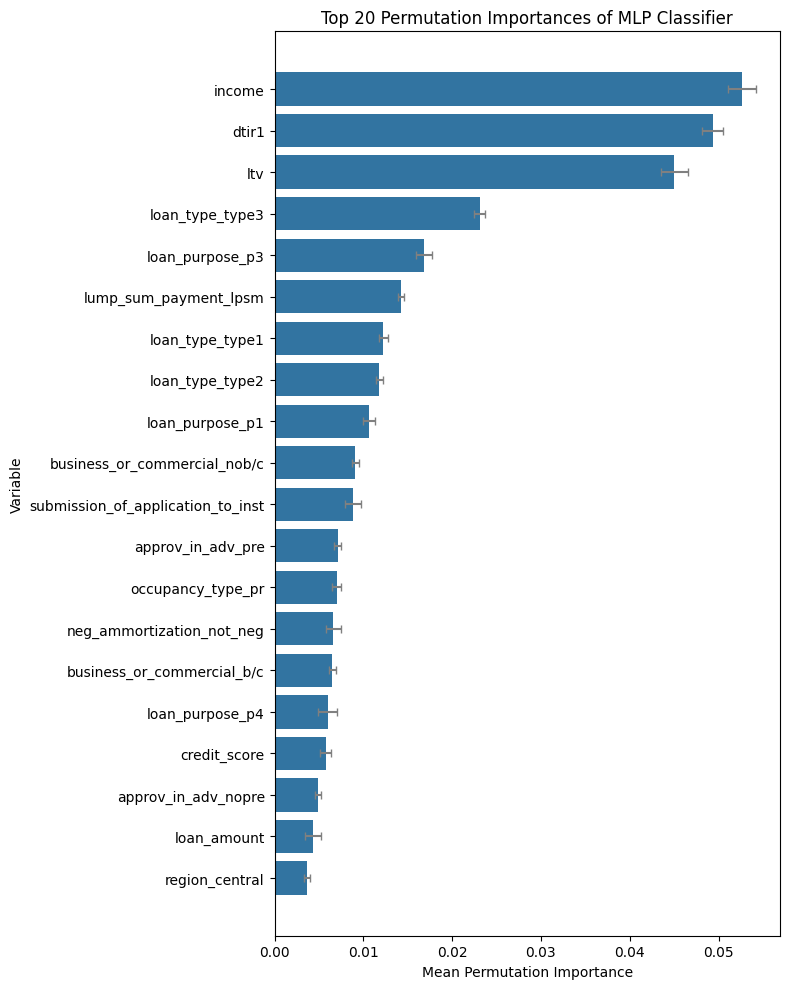

In [11]:
#Nueral_Network

from sklearn.neural_network import MLPClassifier               # Day24
from sklearn.preprocessing import StandardScaler               # Exercise6
from sklearn.model_selection import cross_validate             # Exercise6
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)  # Day24
from sklearn.inspection import permutation_importance          # Day24
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Scale features: StandardScaler is preferred for neural networks over MinMaxScaler
scaler_nn = StandardScaler()                                  # Exercise6
X_train_nn = pd.DataFrame(
    scaler_nn.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_nn = pd.DataFrame(
    scaler_nn.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Define and train the neural network (1 hidden layer, 100 neurons, 500 max iterations)
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)  # Day24
mlp.fit(X_train_nn, y_train)

# Predict and evaluate on test set
y_pred_nn = mlp.predict(X_test_nn)
cm_nn = confusion_matrix(y_test, y_pred_nn)

# Plot confusion matrix for MLPClassifier
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn)
disp.plot(cmap='Blues')
plt.title("Neural Network (MLPClassifier) Confusion Matrix")
plt.show()

# Define scoring metrics for cross-validation
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

# Run 10-fold cross-validation
cv_results_nn = cross_validate(
    mlp,
    X_train_nn,
    y_train,
    cv=10,
    scoring=scoring
)

# Display averaged CV results
print("\nNeural Network CV Stats:")
for metric in scoring:
    mean_val = cv_results_nn[f'test_{metric}'].mean()
    std_val = cv_results_nn[f'test_{metric}'].std()
    print(f"{metric.replace('_', ' ').title()} - CV Avg: {mean_val:.3f}, Std: {std_val:.3f}")

# Compute permutation importances on the training set
perm_import = permutation_importance(
    mlp,
    X_train_nn,
    y_train,
    n_repeats=10,
    random_state=42,
    scoring='balanced_accuracy'
)

# Build DataFrame of means and standard deviations
feat_imp = (
    pd.DataFrame({
        'Variable': X_train_nn.columns,
        'MeanImp': perm_import.importances_mean,
        'StdImp': perm_import.importances_std
    })
    .sort_values('MeanImp', ascending=False)
    .head(20)
)

# Plot the top 20 permutation importances with error bars
plt.figure(figsize=(8, 10))
sns.barplot(data=feat_imp, y='Variable', x='MeanImp', ci=None)
plt.errorbar(
    x=feat_imp['MeanImp'],
    y=np.arange(len(feat_imp)),
    xerr=feat_imp['StdImp'],
    fmt='none',
    ecolor='gray',
    capsize=3
)
plt.xlabel("Mean Permutation Importance")
plt.title("Top 20 Permutation Importances of MLP Classifier")
plt.tight_layout()
plt.show()


